# Un tumor de mama que despierta anticuerpos contra tu cerebro

Un cáncer de mama produce proteínas del cerebro. El sistema inmune las detecta, ataca el tumor... y de paso ataca el cerebro. Es un trade-off brutal: inmunidad anti-cáncer vs daño neurológico.

---

**Paper:** Bhatt, Bhargava, Bhatt et al. (2026) — *Nature*
**DOI:** [10.1038/s41586-026-10278-0](https://doi.org/10.1038/s41586-026-10278-0)
**Video:** [Ver en YouTube](https://youtube.com/watch?v=20DRfz2D5Bg)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-29-cancer-despierta-armas-cerebro/notebook.ipynb)

## El contexto

El cáncer de mama triple negativo (TNBC) es el subtipo más agresivo — no responde a terapias hormonales.

Un equipo liderado por el laboratorio Janowitz confirmó que algunos de estos tumores expresan receptores NMDA (receptores normalmente exclusivos del cerebro). Cuando el sistema inmune los detecta, produce anticuerpos que atacan el tumor. Pero todo apunta a que esos mismos anticuerpos pueden cruzar al cerebro y causar encefalitis anti-NMDAR — una enfermedad autoinmune neurológica grave.

Los datos vienen de experimentos con ratones: tumores ortotópicos (implantados en la mama) con expresión inducible de receptores NMDA. Activar la expresión con doxiciclina (DOX) funciona como un interruptor.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_VOLUMEN = 500        # mm³ — volumen de referencia para "tumor grande"
FUENTE = 'Fuente: Bhatt, Bhargava, Bhatt et al. (2026), Nature | DOI: 10.1038/s41586-026-10278-0'
COLOR_DATOS = '#2563EB'     # Azul CaM
COLOR_ALERTA = '#DC2626'    # Rojo
COLOR_SECUNDARIO = '#059669' # Emerald
COLOR_REFERENCIA = '#D97706' # Amber
COLOR_VIOLETA = '#7C3AED'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Descargar datos si no existen
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
archivos = ['crecimiento_tumor_nmdar.csv', 'tumor_veh_vs_dox.csv',
            'anticuerpos_sk3d_vs_mgo53.csv', 'pacientes_demograficos.csv']
for archivo in archivos:
    if not os.path.exists(f'datos/{archivo}'):
        urllib.request.urlretrieve(f'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-03-29-cancer-despierta-armas-cerebro/datos/{archivo}', f'datos/{archivo}')

# Cargar
df_nmdar = pd.read_csv('datos/crecimiento_tumor_nmdar.csv')
df_veh_dox = pd.read_csv('datos/tumor_veh_vs_dox.csv')
df_anticuerpos = pd.read_csv('datos/anticuerpos_sk3d_vs_mgo53.csv')
df_pacientes = pd.read_csv('datos/pacientes_demograficos.csv')

print(f"Crecimiento NMDAR: {len(df_nmdar)} mediciones, {df_nmdar.mouse_id.nunique()} ratones")
print(f"VEH vs DOX: {len(df_veh_dox)} mediciones, {df_veh_dox.mouse_id.nunique()} ratones")
print(f"Anticuerpos: {len(df_anticuerpos)} mediciones, {df_anticuerpos.mouse_id.nunique()} ratones")
print(f"Pacientes: {len(df_pacientes)} muestras")

Crecimiento NMDAR: 18 mediciones, 3 ratones
VEH vs DOX: 56 mediciones, 10 ratones
Anticuerpos: 21 mediciones, 7 ratones
Pacientes: 63 muestras


## Aquí está.

Veamos qué pasa cuando enciendes los receptores NMDA en un tumor de mama.

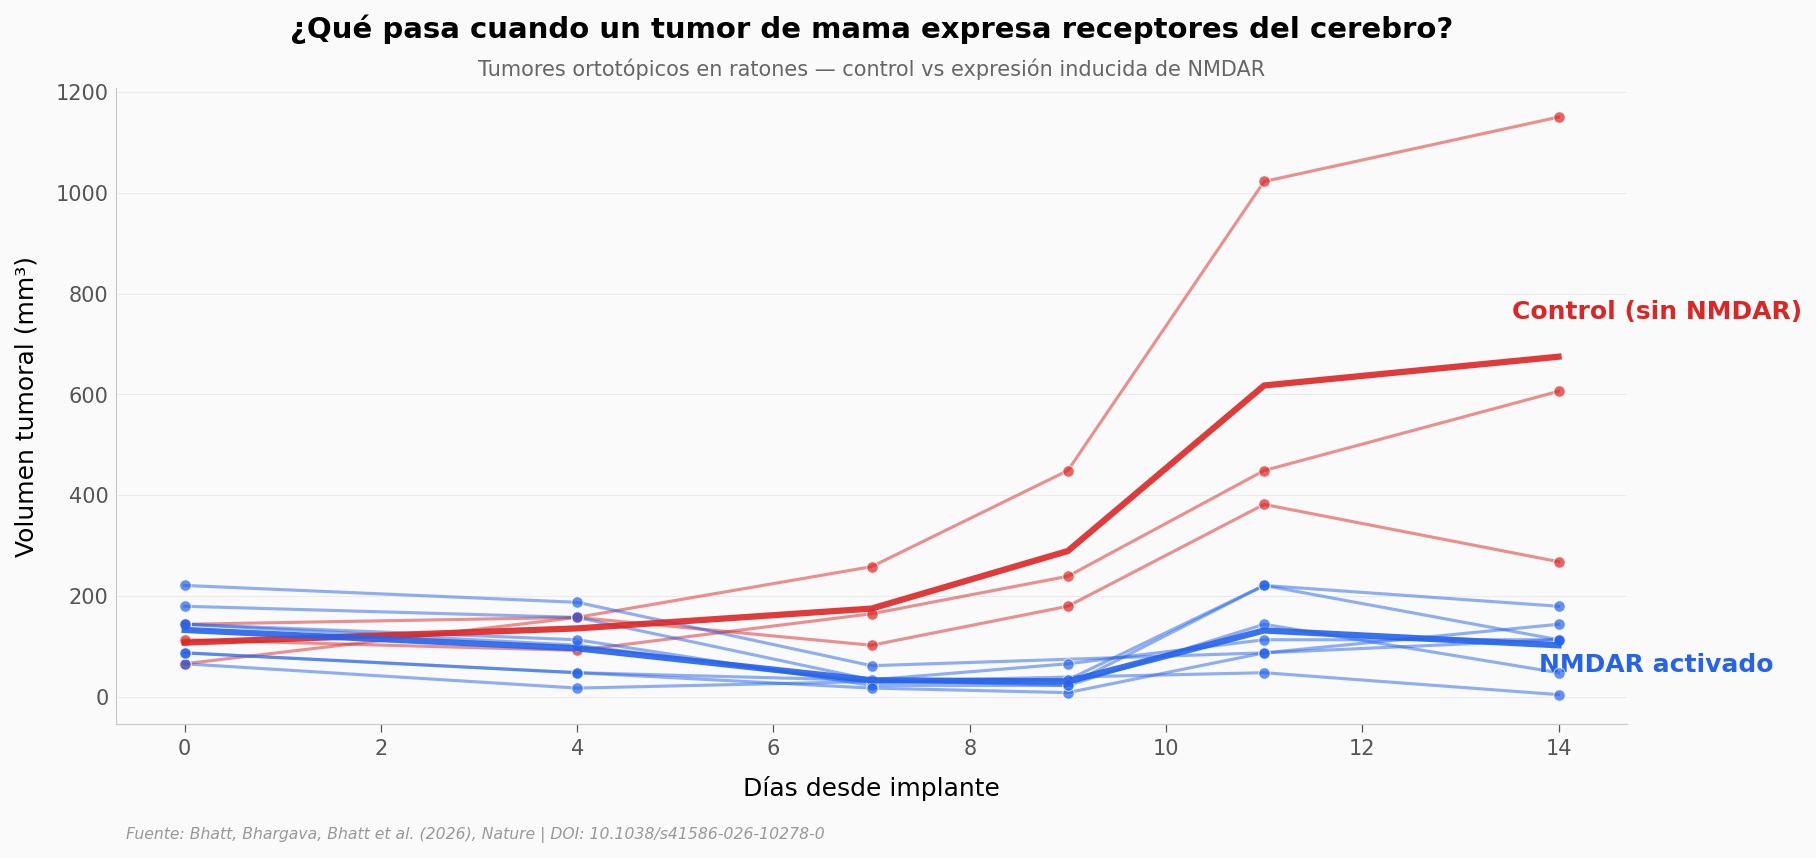

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Convert dates to days from start
df_veh_dox['date'] = pd.to_datetime(df_veh_dox['date'])
start_date = df_veh_dox['date'].min()
df_veh_dox['days'] = (df_veh_dox['date'] - start_date).dt.days

# Plot individual trajectories
for mouse_id in df_veh_dox[df_veh_dox.group == 'VEH']['mouse_id'].unique():
    subset = df_veh_dox[df_veh_dox.mouse_id == mouse_id]
    ax.plot(subset.days, subset.volume_mm3, color=COLOR_ALERTA, alpha=0.5, linewidth=1.5)
    ax.scatter(subset.days, subset.volume_mm3, color=COLOR_ALERTA, s=30, alpha=0.7,
               edgecolors='white', linewidths=0.5, zorder=5)

for mouse_id in df_veh_dox[df_veh_dox.group == 'DOX']['mouse_id'].unique():
    subset = df_veh_dox[df_veh_dox.mouse_id == mouse_id]
    ax.plot(subset.days, subset.volume_mm3, color=COLOR_DATOS, alpha=0.5, linewidth=1.5)
    ax.scatter(subset.days, subset.volume_mm3, color=COLOR_DATOS, s=30, alpha=0.7,
               edgecolors='white', linewidths=0.5, zorder=5)

# Group means
for grp, color, label in [('VEH', COLOR_ALERTA, 'Control (VEH)'),
                            ('DOX', COLOR_DATOS, 'NMDAR activado (DOX)')]:
    means = df_veh_dox[df_veh_dox.group == grp].groupby('days')['volume_mm3'].mean()
    ax.plot(means.index, means.values, color=color, linewidth=3, alpha=0.9, zorder=6)

# Inline labels
ax.text(15, 750, 'Control (sin NMDAR)', fontsize=12, fontweight='bold',
        color=COLOR_ALERTA, ha='center')
ax.text(15, 50, 'NMDAR activado', fontsize=12, fontweight='bold',
        color=COLOR_DATOS, ha='center')

ax.set_xlabel('Días desde implante')
ax.set_ylabel('Volumen tumoral (mm³)')
ax.set_title('¿Qué pasa cuando un tumor de mama expresa receptores del cerebro?',
             fontsize=14, fontweight='bold')
ax.text(0.5, 1.02, 'Tumores ortotópicos en ratones — control vs expresión inducida de NMDAR',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/veh_vs_dox_crecimiento.png', dpi=200, bbox_inches='tight')
plt.show()

Cada línea es un ratón individual. Las líneas rojas son tumores control (sin receptores NMDA) — crecen sin freno, algunos superan los 1,000 mm³. Las líneas azules son tumores donde se activó la expresión de receptores NMDA con doxiciclina.

La diferencia al final del experimento: los tumores control alcanzan una media de 675 mm³, mientras que los tumores con NMDAR se quedan en 102 mm³ — un **85% menos** (Mann-Whitney p = 0.021, Cohen's d = 2.51, n = 3 control + 7 DOX).

⚠️ **Ojo con la n:** solo 3 ratones en el grupo control. El efecto es enorme (d = 2.51) pero la muestra es pequeña.

## El colapso individual

Los tumores con NMDAR no solo crecen menos — algunos colapsan completamente. Veamos las trayectorias individuales.

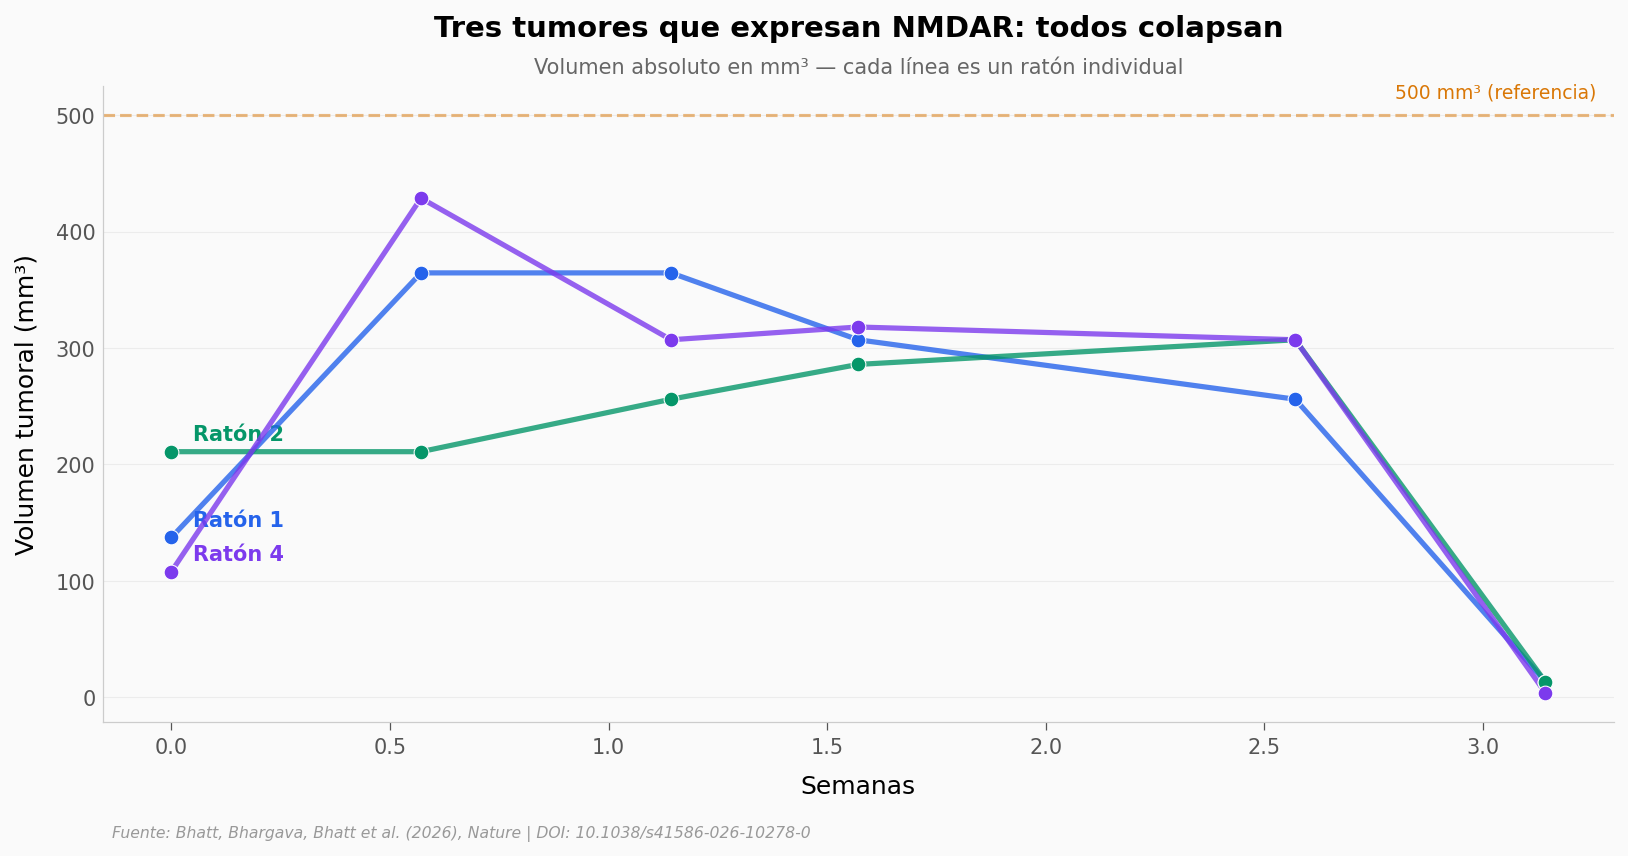

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

colors = [COLOR_DATOS, COLOR_SECUNDARIO, COLOR_VIOLETA]
for i, mouse_id in enumerate(df_nmdar.mouse_id.unique()):
    subset = df_nmdar[df_nmdar.mouse_id == mouse_id]
    ax.plot(subset.time_weeks, subset.volume_mm3, color=colors[i],
            linewidth=2.5, alpha=0.8, zorder=5)
    ax.scatter(subset.time_weeks, subset.volume_mm3, color=colors[i],
               s=50, edgecolors='white', linewidths=0.5, zorder=6)
    # Label at start
    ax.text(0.05, subset.iloc[0].volume_mm3 + 10, f'Ratón {mouse_id}',
            fontsize=10, fontweight='bold', color=colors[i])

# Reference line
ax.axhline(y=UMBRAL_VOLUMEN, color=COLOR_REFERENCIA, linewidth=1.5,
           linestyle='--', alpha=0.5)
ax.text(2.8, UMBRAL_VOLUMEN + 15, f'{UMBRAL_VOLUMEN} mm³ (referencia)',
        fontsize=9, color=COLOR_REFERENCIA)

ax.set_xlabel('Semanas')
ax.set_ylabel('Volumen tumoral (mm³)')
ax.set_title('Tres tumores que expresan NMDAR: todos colapsan',
             fontsize=14, fontweight='bold')
ax.text(0.5, 1.02, 'Volumen absoluto en mm³ — cada línea es un ratón individual',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/colapso_individual.png', dpi=200, bbox_inches='tight')
plt.show()

## Los anticuerpos importan

El cuerpo produce anticuerpos contra esos receptores NMDA del tumor. Pero no todos hacen lo mismo — algunos **potencian** los receptores (los hacen más activos) y otros los **inhiben**.

El equipo inyectó anticuerpos directamente (transferencia pasiva) en ratones con tumores para ver qué pasa:
- **sk3d** — un anticuerpo que potencia los receptores NMDA
- **mgo53** — un anticuerpo control

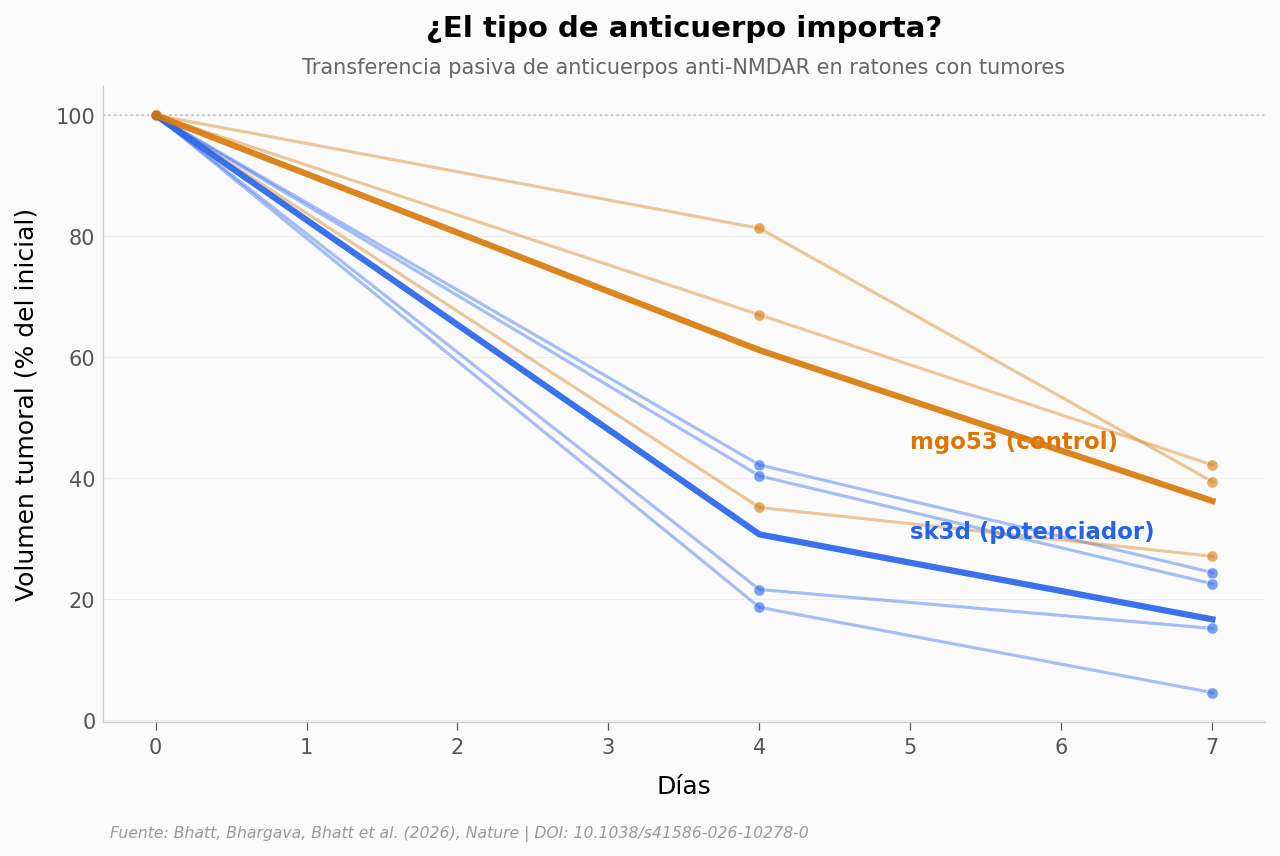

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# Plot individual mice
for mouse_id in df_anticuerpos[df_anticuerpos.group == 'sk3d']['mouse_id'].unique():
    subset = df_anticuerpos[df_anticuerpos.mouse_id == mouse_id]
    ax.plot(subset.time_days, subset.volume_norm_pct, color=COLOR_DATOS, alpha=0.4, linewidth=1.5)
    ax.scatter(subset.time_days, subset.volume_norm_pct, color=COLOR_DATOS, s=30, alpha=0.6,
               edgecolors='white', linewidths=0.5, zorder=5)

for mouse_id in df_anticuerpos[df_anticuerpos.group == 'mgo53']['mouse_id'].unique():
    subset = df_anticuerpos[df_anticuerpos.mouse_id == mouse_id]
    ax.plot(subset.time_days, subset.volume_norm_pct, color=COLOR_REFERENCIA, alpha=0.4, linewidth=1.5)
    ax.scatter(subset.time_days, subset.volume_norm_pct, color=COLOR_REFERENCIA, s=30, alpha=0.6,
               edgecolors='white', linewidths=0.5, zorder=5)

# Group means
for grp, color in [('sk3d', COLOR_DATOS), ('mgo53', COLOR_REFERENCIA)]:
    means = df_anticuerpos[df_anticuerpos.group == grp].groupby('time_days')['volume_norm_pct'].mean()
    ax.plot(means.index, means.values, color=color, linewidth=3, alpha=0.9, zorder=6)

ax.axhline(y=100, color='#999999', linewidth=1, linestyle=':', alpha=0.5)

# Inline labels
ax.text(5, 30, 'sk3d (potenciador)', fontsize=11, fontweight='bold', color=COLOR_DATOS)
ax.text(5, 45, 'mgo53 (control)', fontsize=11, fontweight='bold', color=COLOR_REFERENCIA)

ax.set_xlabel('Días')
ax.set_ylabel('Volumen tumoral (% del inicial)')
ax.set_title('¿El tipo de anticuerpo importa?',
             fontsize=14, fontweight='bold')
ax.text(0.5, 1.02, 'Transferencia pasiva de anticuerpos anti-NMDAR en ratones con tumores',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anticuerpos_comparacion.png', dpi=200, bbox_inches='tight')
plt.show()

Los tumores tratados con sk3d (el potenciador) bajan al **17% del volumen original** al día 7, mientras que los tratados con mgo53 bajan al **36%** (Cohen's d = 2.27, n = 4 + 3).

La diferencia no alcanza significancia estadística (Mann-Whitney p = 0.057) — con solo 7 ratones es difícil. Pero el tamaño del efecto es enorme.

## ¿Qué tan extrema es la reducción?

Veamos dónde caen estos tumores en la distribución general de volúmenes.

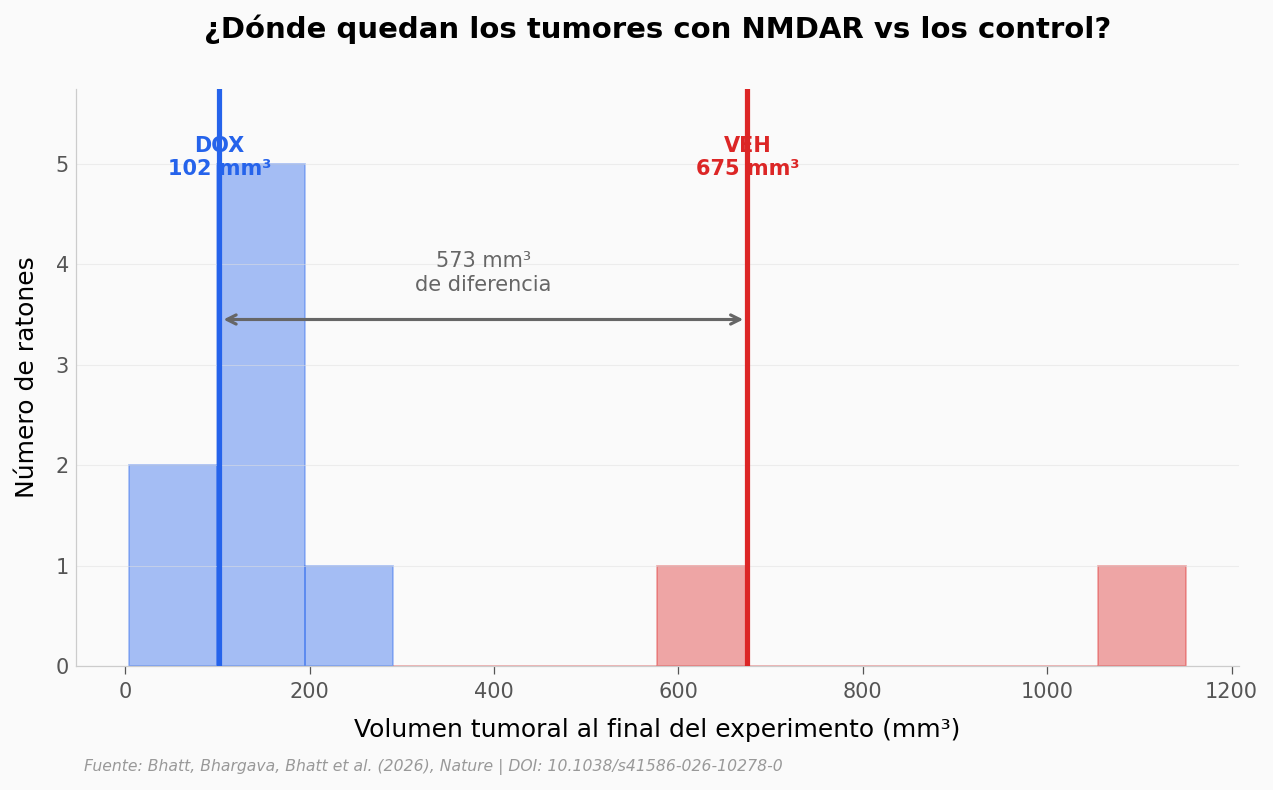

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# All final volumes from VEH vs DOX experiment
last_date = df_veh_dox['date'].max()
all_final = df_veh_dox[df_veh_dox.date == last_date]['volume_mm3']
veh_final = df_veh_dox[(df_veh_dox.date == last_date) & (df_veh_dox.group == 'VEH')]['volume_mm3']
dox_final = df_veh_dox[(df_veh_dox.date == last_date) & (df_veh_dox.group == 'DOX')]['volume_mm3']

n, bins, patches = ax.hist(all_final, bins=12, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)

# Color VEH bars differently
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge >= 200:
        patch.set_facecolor(COLOR_ALERTA)
        patch.set_edgecolor(COLOR_ALERTA)
        patch.set_alpha(0.4)

y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

# Reference lines
media_dox = dox_final.mean()
media_veh = veh_final.mean()
ax.axvline(x=media_dox, color=COLOR_DATOS, linewidth=2.5, zorder=7)
ax.axvline(x=media_veh, color=COLOR_ALERTA, linewidth=2.5, zorder=7)

# Arrow
ax.annotate('', xy=(media_veh, y_max*0.6), xytext=(media_dox, y_max*0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((media_dox + media_veh)/2, y_max*0.65, f'{media_veh - media_dox:.0f} mm³\nde diferencia',
        fontsize=10, ha='center', color='#666666')

# Labels
ax.text(media_dox, y_max*0.85, f'DOX\n{media_dox:.0f} mm³', fontsize=10,
        fontweight='bold', color=COLOR_DATOS, ha='center')
ax.text(media_veh, y_max*0.85, f'VEH\n{media_veh:.0f} mm³', fontsize=10,
        fontweight='bold', color=COLOR_ALERTA, ha='center')

ax.set_xlabel('Volumen tumoral al final del experimento (mm³)')
ax.set_ylabel('Número de ratones')
ax.set_title('¿Dónde quedan los tumores con NMDAR vs los control?',
             fontsize=14, fontweight='bold')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_volumenes.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Tumores con NMDAR son más pequeños que los control | ✅ | Media 102 vs 675 mm³, p = 0.021, d = 2.51, n = 7 + 3 |
| Los 3 tumores NMDAR individuales colapsan | ⚠️ | De ~152 a ~10 mm³ (-93%), d = 2.88 (pareado). Wilcoxon p = 0.250, n = 3 — efecto consistente pero muestra insuficiente para significancia |
| sk3d reduce más que mgo53 | ⚠️ | 17% vs 36% del original, d = 2.27 (enorme), pero p = 0.057, n = 4 + 3 |
| Los anticuerpos anti-NMDAR causan encefalitis | ⚠️ | El paper lo muestra con transferencia pasiva (no en estos datos — Fig. 5 del paper, no incluida aquí) |
| Trade-off inmunidad anti-cáncer vs autoinmunidad | ✅ | Tesis central del paper, soportada por el conjunto de evidencia |

> **Limitaciones:**
> - Tamaños de muestra muy pequeños (n = 3-7 por grupo). Los efectos son dramáticos (d > 2.0) pero la potencia estadística es baja.
> - Los datos aquí son de ratones con tumores ortotópicos — la extrapolación a humanos requiere cautela.
> - No tenemos acceso a los datos de encefalitis (Fig. 5) ni a la correlación en pacientes (Fig. 6f-g) — esos datos están en formatos restringidos (scRNA-seq, Visium HD).
> - El paper usa "suggests" y "consistent with" — los autores no afirman causalidad directa entre la expresión tumoral de NMDAR y la encefalitis en humanos.

## Ahora tú

Tres preguntas para explorar con estos datos:

1. **¿Hay ratones DOX que no respondieron?** Los 7 ratones DOX muestran reducción, pero ¿alguno tiene un volumen final comparable al grupo control? (Pista: filtra `df_veh_dox` por grupo y fecha final)

2. **¿Cuánto tarda en aparecer el efecto?** En la gráfica de colapso individual, los tumores crecen las primeras semanas antes de caer. ¿En qué semana empieza la caída? (Pista: busca el `time_weeks` donde `volume_mm3` alcanza su pico para cada ratón)

3. **¿El tamaño inicial predice la respuesta?** ¿Los tumores que empiezan más grandes colapsan más rápido, o da igual el tamaño inicial? (Pista: correlaciona volumen en semana 0 con el porcentaje de reducción)

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Hay ratones DOX que se escaparon del efecto?

last_date = df_veh_dox['date'].max()
final = df_veh_dox[df_veh_dox.date == last_date].copy()
final = final.sort_values('volume_mm3', ascending=False)

print("Volumen final por ratón (mayor a menor):")
print("="*50)
for _, row in final.iterrows():
    emoji = '🔴' if row.group == 'VEH' else '🔵'
    print(f"  {emoji} {row.mouse_id:>5} ({row.group}): {row.volume_mm3:>8.1f} mm³")

# ¿Algún DOX supera al menor VEH?
min_veh = final[final.group == 'VEH']['volume_mm3'].min()
dox_above = final[(final.group == 'DOX') & (final.volume_mm3 > min_veh)]
print(f"\nMenor VEH: {min_veh:.1f} mm³")
print(f"DOX que lo superan: {len(dox_above)}")
if len(dox_above) == 0:
    print("→ Ningún ratón DOX alcanza siquiera al menor control")

Volumen final por ratón (mayor a menor):
  🔴   A_4 (VEH):   1150.3 mm³
  🔴   A_0 (VEH):    606.1 mm³
  🔴   A_2 (VEH):    268.1 mm³
  🔵   D_0 (DOX):    179.6 mm³
  🔵   F_3 (DOX):    143.8 mm³
  🔵   D_3 (DOX):    113.1 mm³
  🔵   D_4 (DOX):    113.1 mm³
  🔵   F_1 (DOX):    113.1 mm³
  🔵   F_2 (DOX):     47.7 mm³
  🔵   F_0 (DOX):      4.2 mm³

Menor VEH: 268.1 mm³
DOX que lo superan: 0
→ Ningún ratón DOX alcanza siquiera al menor control


---

## Créditos

- **Paper:** Bhatt, Bhargava, Bhatt et al. (2026). *Tumour NMDA receptor expression links anti-cancer and autoimmunity.* Nature.
- **DOI:** [10.1038/s41586-026-10278-0](https://doi.org/10.1038/s41586-026-10278-0)
- **Datos:** Supplementary Table 6 (Source Data) — [Nature](https://doi.org/10.1038/s41586-026-10278-0)
- **Código original:** [github.com/Janowitz-Lab/nmdar](https://github.com/Janowitz-Lab/nmdar)
- **Licencia datos:** Los datos se redistribuyen con fines educativos bajo fair use académico.
- **Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)